# De novo regulatory peak discovery

Scan every promoter × growth-condition pair for **de novo** regulatory
features — positions where mutations significantly change expression but
that fall *outside* the canonical promoter window (-55..0 around the TSS).
These are candidate non-canonical regulatory elements, e.g. distal
activator sites, downstream regulators, or 5′ UTR elements.

The two main steps:

1. `run_scan` — for each (promoter, condition), call MI peaks above an
   `a/N` background floor and a z-score cutoff, classify each peak as
   canonical or de novo by position, and tabulate the per-peak expression
   shifts.
2. **Recurrence aggregation** — count how often each de novo peak
   re-appears across the 80+ growth conditions. Peaks that recur in many
   conditions are stronger candidates than those that appear once.


In [1]:
import pandas as pd
from glob import glob
import numpy as np
from numba import njit

from matplotlib import font_manager
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import itertools
import phd_pkg  # in-repo helper package: viz styling + colour palette

from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
from matplotlib import collections  as mc
import matplotlib.colors as mcolors

phd_pkg.viz.matplotlib_style()
phd_pkg.viz.my_color_dict

# denovo_scanner is the module that does the per-promoter MI peak calling.
# build_wt_dict / load_df_map are convenience loaders we don't use directly here
# (we build df_map and wt_dict inline below) but are imported for completeness.
from denovo_scanner import build_wt_dict, run_scan, save_outputs, load_df_map


In [3]:
# Barcode → promoter map (one row per mapped barcode, with `name` = promoter id).
df_map = pd.read_csv("../data/mapping/mapped_barcodes_filtered.csv")


# ----------------------------
# Global figure + font settings
# ----------------------------
FIG_WIDTH = 7.0
FIG_HEIGHT = 3.0

mpl.rcParams.update({
    # Figure geometry
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Fonts
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Lines / markers
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes styling
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Mathtext / fonts (no external LaTeX dependency)
    #"mathtext.fontset": "stix",
    #"font.family": "STIXGeneral",
})



In [4]:
# WT (un-mutated) sequence per promoter — keyed by promoter `name` for fast lookup
# inside the scan. Note: relative path goes via the parent of the repo.
df_wt = pd.read_csv("../../reg-seq_env/data/metadata/wt_sequences.csv")[['promoter_seq', 'promoter']]
wt_dict = dict(zip(df_wt['promoter'].values, df_wt['promoter_seq'].values))
df_wt


,promoter_seq,promoter
0,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,rspAp
1,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,araBp
2,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,znuCp
3,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,xylAp
4,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,xylFp
...,...,...
112,TGGTGCTGGTTATCAGCACTGAAGGCGACACCGACGTGAAGCACTA...,ygeY_predicted
113,CGCTGGACGAAATCCGCGCCCTGCCTGCAGTACAGAAAGCTAACGC...,hyuA_predicted
114,TCGGACATGTTTGAAGAGATGAAATTTGCCTTCTTTAAACATCGCG...,ygfM_xdhD_predicted
115,AGTGCCAGTTTTTGCGAGGAAGGGGAGTTAGAGACAGGAATTGCGG...,ygfS_ygfT_predicted


In [2]:
# List growth condition indices from the DNA barcode files (each ind = one sample).
files = np.hstack([glob("../../reg-seq_env/data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])

# Drop samples that failed QC (low coverage, contamination, etc.) — same exclusion
# list as compute_footprints.ipynb.
inds = [file for file in inds if not np.any([y == file for y in  ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2','4-1', '31-2', '20-2', '13-2', '26-1', '26-2']])]


## Run the scan

`run_scan` returns one row per called peak (per promoter, per condition).
`save_outputs` writes per-promoter candidate tables under `denovo_results/`.

- `noise_a=8.13` is the background-MI fit `a` from `compute_footprints.ipynb`
  (MI floor scales as `a / N`).
- `mi_z=3.0` is the z-score cutoff for calling a peak above background.


  1-1 ... 112 promoters done
  1-2 ... 112 promoters done
  10-1 ... 112 promoters done
  10-2 ... 112 promoters done
  11-1 ... 112 promoters done
  11-2 ... 112 promoters done
  12-1 ... 112 promoters done
  12-2 ... 112 promoters done
  13-1 ... 112 promoters done
  13-3 ... 112 promoters done
  14-1 ... 112 promoters done
  14-2 ... 112 promoters done
  15-2 ... 112 promoters done
  15-3 ... 112 promoters done
  16-1 ... 112 promoters done
  16-2 ... 112 promoters done
  17-1 ... 112 promoters done
  17-2 ... 112 promoters done
  18-1 ... 112 promoters done
  18-2 ... 112 promoters done
  19-2 ... 112 promoters done
  19-3 ... 112 promoters done
  2-1 ... 112 promoters done
  2-2 ... 112 promoters done
  20-1 ... 112 promoters done
  20-3 ... 112 promoters done
  21-1 ... 112 promoters done
  21-2 ... 112 promoters done
  22-2 ... 112 promoters done
  22-3 ... 112 promoters done
  23-1 ... 112 promoters done
  23-2 ... 112 promoters done
  24-1 ... 112 promoters done
  24-2 ... 112

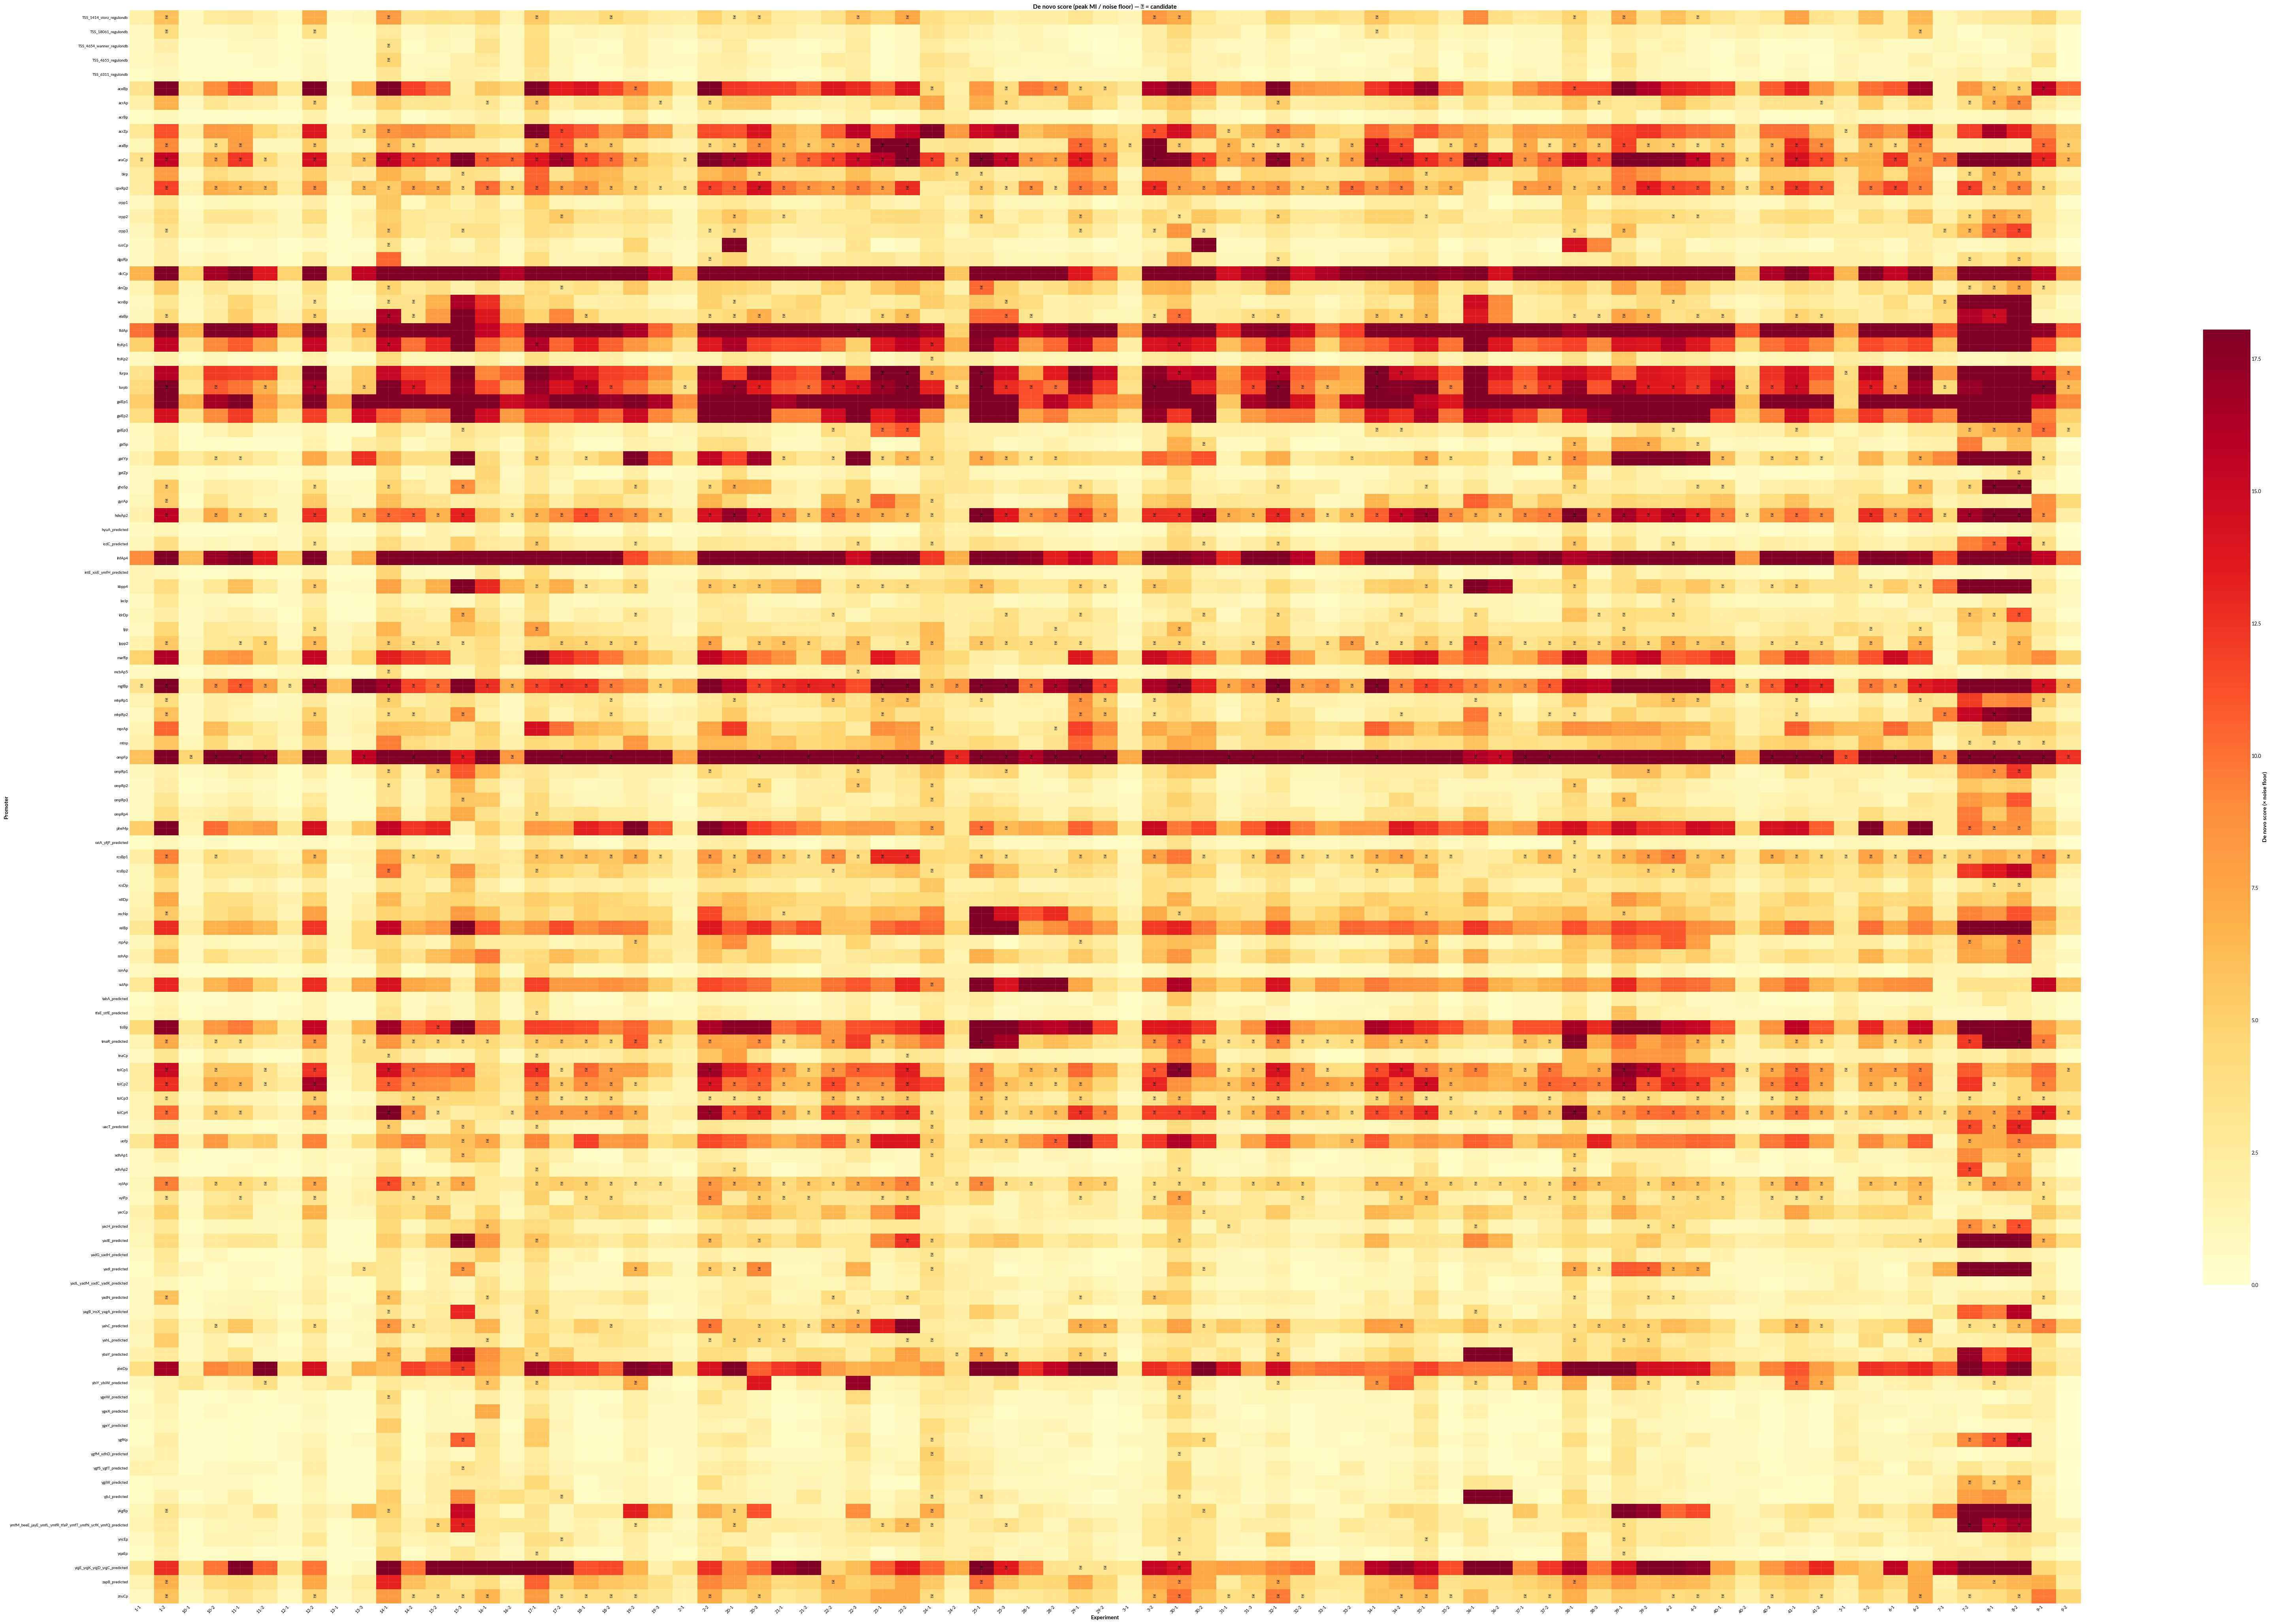

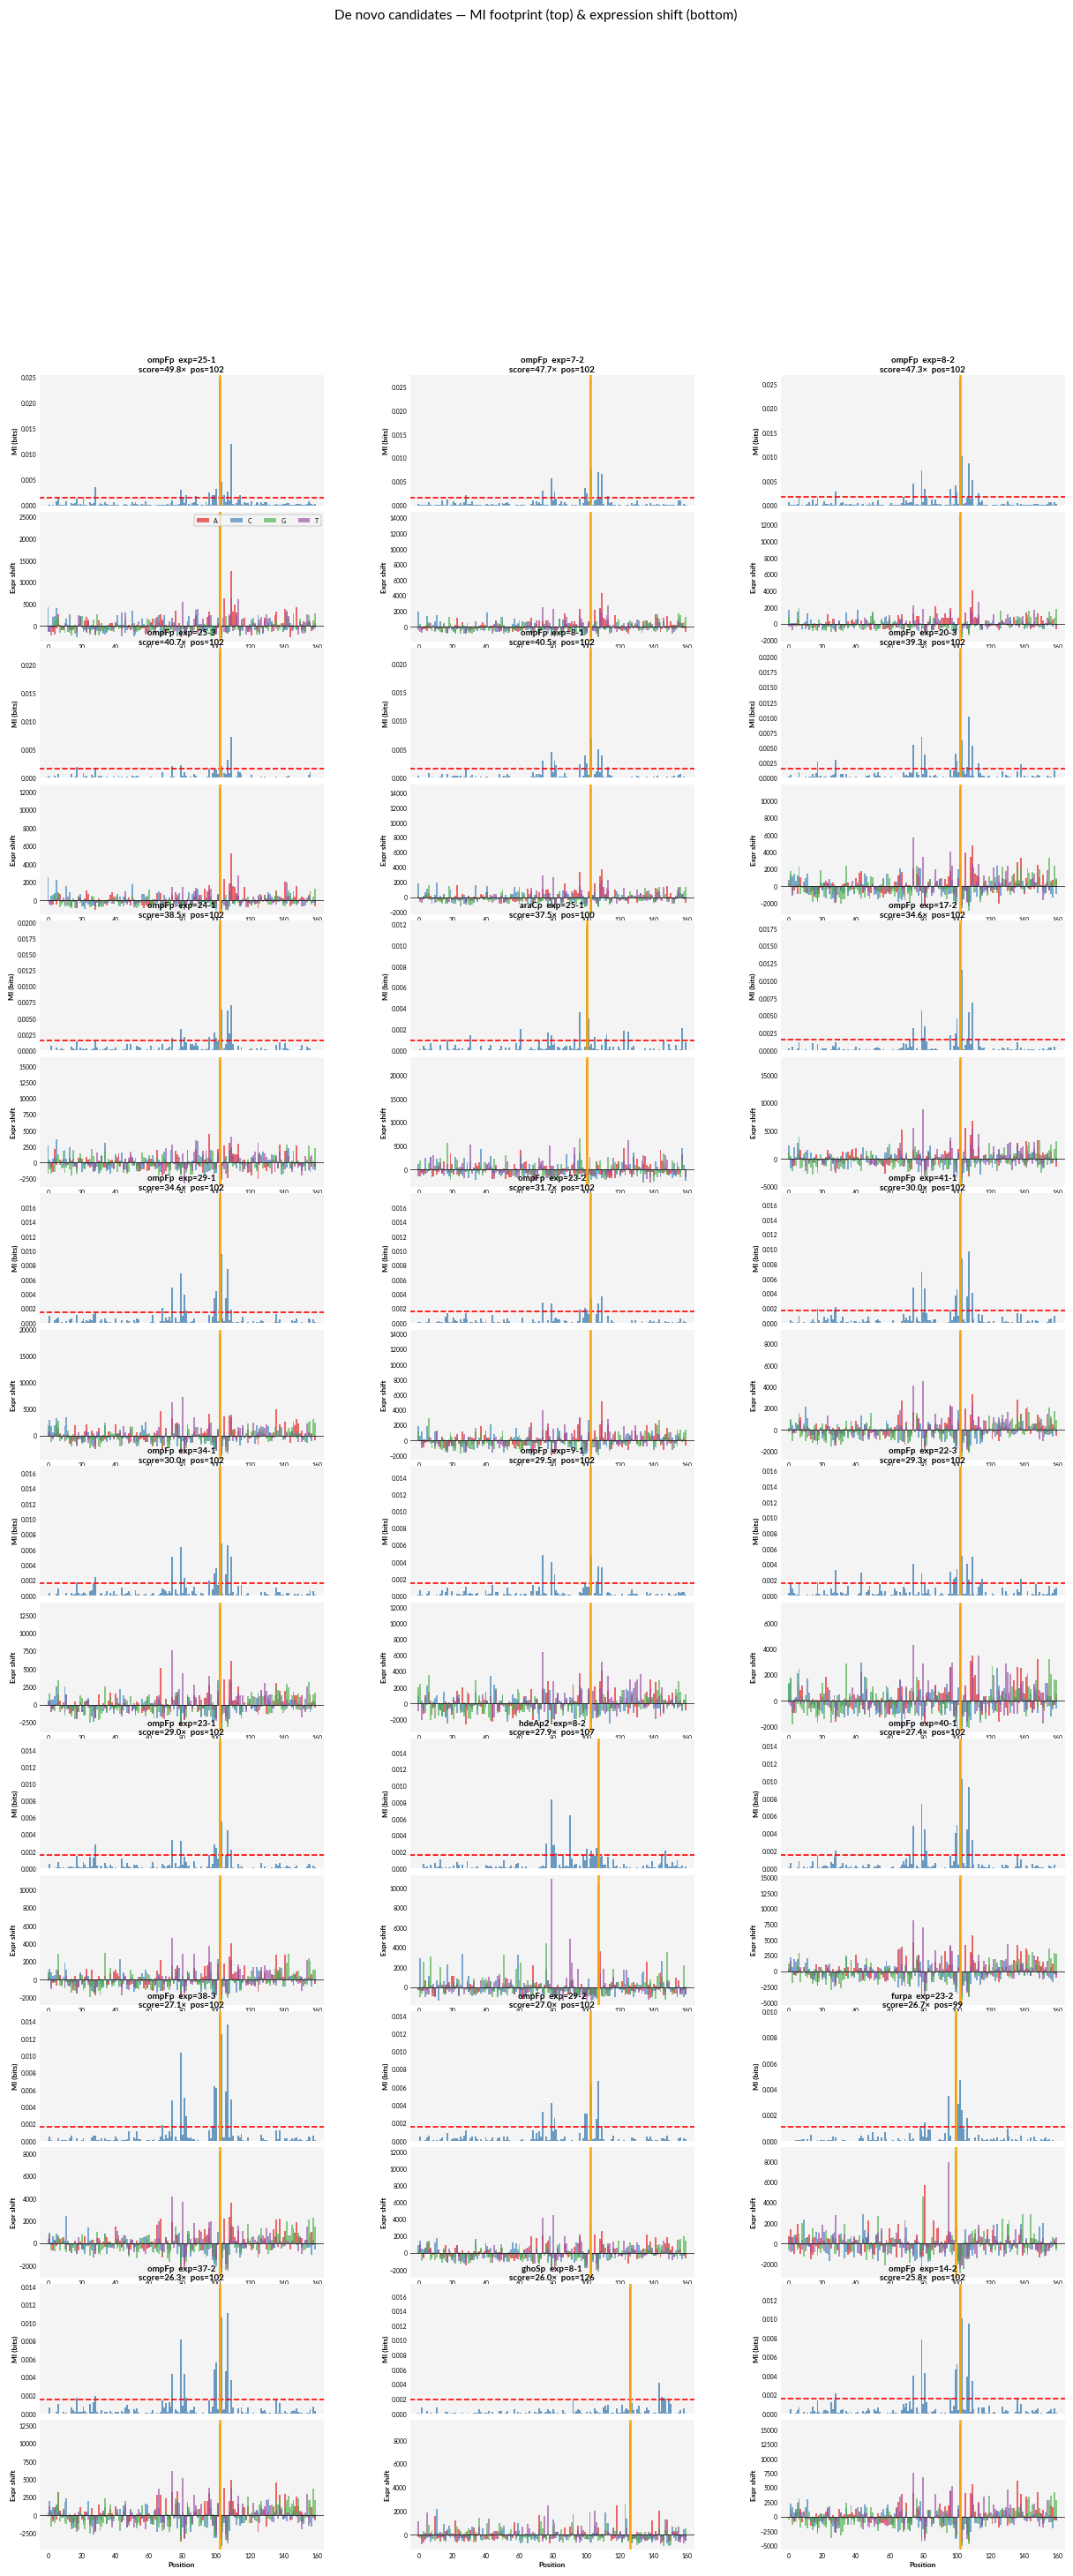

In [17]:
# Run the per-promoter MI peak scan across every (promoter, condition) pair.
# `df_results` has one row per called peak; `save_outputs` also writes per-promoter
# candidate tables under denovo_results/ for downstream inspection.
indices = inds

df_results = run_scan(
    indices=indices,
    df_map=df_map,
    wt_dict=wt_dict,
    data_dir="../../reg-seq_env/data/extracted_barcodes",
    noise_a=8.13,        # background-MI fit (a / N) from compute_footprints.ipynb
    mi_z=3.0,            # z-score cutoff for calling a peak above background
    #expr_shift_thresh=0.1,
)

candidates = save_outputs(
    df_results, indices, df_map, wt_dict,
    data_dir="../../reg-seq_env/data/extracted_barcodes",
    noise_a=8.13, mi_z=3.0,
    output_dir="./denovo_results",
)


In [23]:
# scratch: how many growth conditions are in the scan.
len(inds)


79

## Recurrent de novo peaks across conditions

Filter to peaks flagged `is_denovo` and falling outside the canonical
promoter window (in the un-shifted coordinate that's `peak_pos < 60` →
upstream of -55, or `peak_pos > 115` → at/downstream of the TSS), then
group by (promoter, peak_pos) and count how often each one shows up across
all conditions. Top 50 are kept and positions converted to TSS-relative.


In [29]:
# Top recurrent de novo peaks across conditions.
#
# Filter rules (peak_pos is in the un-shifted 0..159 frame, where 115 = TSS):
#   - is_denovo: peak called outside the canonical promoter region by run_scan
#   - peak_pos < 60  → upstream of -55 from TSS (distal upstream sites)
#   - peak_pos > 115 → at or downstream of the TSS (UTR / leader sites)
# Then group by (promoter, peak_pos), count occurrences, take the top 50,
# convert to a fraction-of-conditions metric, and shift to TSS-relative coords.
df_tot = df_results[(df_results['is_denovo'].values) & ([(x < 60) or (x > 115) for x in df_results['peak_pos']])].groupby(['promoter', 'peak_pos']).size().reset_index().sort_values(by=0, ascending=False).head(50)
df_tot['fraction_de_novo'] = df_tot[0]/len(inds)
df_tot['peak_pos'] = df_tot['peak_pos'] -115
df_tot


,promoter,peak_pos,0,fraction_de_novo
67,tolCp4,-110,63,0.797468
6,cpxRp2,-77,58,0.734177
39,mglBp,30,54,0.683544
77,xylAp,-68,53,0.670886
35,lppp2,-88,51,0.645570
4,araBp,-77,47,0.594937
63,tolCp3,-98,30,0.379747
57,rcsBp1,13,27,0.341772
115,znuCp,-89,20,0.253165
40,mhpRp1,8,16,0.202532


## Salis-model emerging promoters

Take a list of `(promoter, gc, rep)` targets — typically the recurrent peaks
from the section above — and ask the Salis-lab promoter calculator whether the
single most-impactful mutation at that position creates or shifts a putative
TSS. For each target:

1. `get_seqs` finds the dominant mutation (highest expression shift) in the
   `gc-rep` library and splits library variants into "carries the mutation"
   vs. "does not".
2. The Salis calculator scans both pools for putative TSSs; we average
   transcription-rate predictions per TSS position across each pool.
3. The output is a long-format table with one row per (target, pos), with
   `rates_w_mutation` and `rates_wo_mutation` columns ready for plotting.

Replaces the old `df_triage`-based iteration with an explicit list-of-targets
function call.


In [ ]:
# Imports for the Salis-model section.
import regseq2  # provides regseq2.promoter_calculator.Promoter_Calculator
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import copy


In [ ]:
# Library variant sequences (one row per (promoter, barcode-region)) — used by
# get_seqs to look up which variants carry which mutation.
df_seqs = pd.read_csv("../../data/metadata/twist_order_sequences.csv")

# Growth-condition metadata (Index → human-readable Condition name).
growth_conditions = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=';')


In [ ]:
# ── Helpers for the Salis emerging-promoter analysis ────────────────────────

dict_int_to_base = {'1': 'A', '2': 'C', '3': 'G', '4': 'T'}


def reverse_complement(dna):
    complements = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return "".join(complements[base] for base in reversed(dna))


def get_seqs(prom, gc, rep):
    """For (promoter, gc, rep), find the position+base with the largest
    expression shift, then split df_seqs library variants into pools that
    carry vs. don't carry that mutation.

    Returns
    -------
    seqs_w_mut, seqs_wo_mut, pos : list[str], list[str], int
        Variant sequences (160 nt, the mutated region) and the TSS-relative
        position of the dominant mutation.
    """
    df = pd.read_csv(f"../../data/expression_shifts/{gc}-{rep}_exshifts.csv")
    df = df[df['promoter'] == prom]
    ind = np.argmax(df['expression_shift'].values)
    pos = df['pos'].values[ind]
    base = dict_int_to_base[f"{df['base'].values[ind]}"]
    seqs_w_mut = [x[26:186] for x in df_seqs.loc[df_seqs['promoter'] == prom, 'sequence'].values
                  if list(x[26:186])[pos + 115] == base]
    seqs_wo_mut = [x[26:186] for x in df_seqs.loc[df_seqs['promoter'] == prom, 'sequence'].values
                   if list(x[26:186])[pos + 115] != base]
    return seqs_w_mut, seqs_wo_mut, pos


def process_sequence(seq,
                     pre_sequence="AGTGCCATGTTATCCCTGAATCTAGT",
                     trail_sequence="ctcatcagaccggaaagcacatccggtgacagctGGGCCC".upper(),
                     return_TSS=False):
    """Run the Salis-lab promoter calculator on `pre + seq + trail` and
    return per-TSS Tx_rate values (optionally with TSS positions).
    """
    p = regseq2.promoter_calculator.Promoter_Calculator()
    full_seq = pre_sequence + seq + trail_sequence
    p.run(full_seq)
    output = p.output()
    if return_TSS:
        return [(output['Forward_Predictions_per_TSS'][k]['TSS'],
                 output['Forward_Predictions_per_TSS'][k]['Tx_rate'])
                for k in output['Forward_Predictions_per_TSS']]
    return [output['Forward_Predictions_per_TSS'][k]['Tx_rate']
            for k in output['Forward_Predictions_per_TSS']]


def find_loc(promoter):
    """Look up `promoter`'s 160 nt mutated region in the MG1655 genome and
    return the genomic 26 nt upstream and 40 nt downstream flanks (oriented
    5' → 3' on the promoter strand). Used as `pre_sequence` / `trail_sequence`
    for the Salis calculator when `use_genomic_flanks=True`.
    """
    with open("../../data/metadata/mg1655_genome.fasta", 'r') as file:
        lines = file.readlines()
    sequence = ''.join(line.strip() for line in lines if not line.startswith('>'))
    seq = df_seqs.loc[df_seqs['promoter'] == promoter, 'sequence'].values[0][26:186]

    loc = sequence.find(seq)
    direction = 1
    if loc == -1:
        loc = sequence.find(reverse_complement(seq))
        direction = -1
    if loc == -1:
        raise Exception("Promoter location not found")

    if direction == 1:
        return sequence[loc - 115 - 26:loc - 115], sequence[loc + 45:loc + (45 + 40)]
    else:
        return reverse_complement(sequence[loc + 115:loc + 115 + 26]), reverse_complement(sequence[loc - 45 - 40:loc - 45])


In [ ]:
def compute_emerging_promoter_rates(
    promoter_names,
    gcs,
    reps,
    *,
    use_genomic_flanks=False,
    n_jobs=20,
    output_csv=None,
):
    """Salis-lab emerging-promoter analysis for a parallel list of targets.

    For each (promoter, gc, rep), find the most-impactful mutation in the
    expression-shift table, split library variants by whether they carry it,
    and average per-TSS transcription rates predicted by the Salis-lab
    promoter calculator.

    Parameters
    ----------
    promoter_names, gcs, reps : list-like
        Parallel lists of equal length describing the targets.
    use_genomic_flanks : bool
        If True, use `find_loc` to pull the flanking pre/trail sequences from
        the MG1655 genome; otherwise use the constant flanks from the library.
    n_jobs : int
        Parallelism passed to joblib.
    output_csv : str | None
        If set, also write the long-format result to this path.

    Returns
    -------
    pandas.DataFrame
        Columns: promoter, gc, rep, pos, rates_w_mutation, rates_wo_mutation.
    """
    if not (len(promoter_names) == len(gcs) == len(reps)):
        raise ValueError("promoter_names, gcs, reps must all be the same length")

    df_out = []
    for promoter, gc, rep in tqdm(zip(promoter_names, gcs, reps), total=len(promoter_names)):
        seqs_w, seqs_wo, pos = get_seqs(promoter, gc, rep)

        if use_genomic_flanks:
            pre_sequence, trail_sequence = find_loc(promoter)
            zero_pos = 58 - len(pre_sequence) - 115
            kwargs = dict(pre_sequence=pre_sequence, trail_sequence=trail_sequence)
        else:
            zero_pos = 58 - 26 - 115  # default 26 nt pre + 115 nt mutated region
            kwargs = {}

        rates_w = Parallel(n_jobs=n_jobs)(
            delayed(process_sequence)(seq, **kwargs) for seq in seqs_w
        )
        rates_wo = Parallel(n_jobs=n_jobs)(
            delayed(process_sequence)(seq, **kwargs) for seq in seqs_wo
        )

        mean_rates_w = np.mean(rates_w, axis=0)
        mean_rates_wo = np.mean(rates_wo, axis=0)
        positions = list(range(zero_pos, zero_pos + len(mean_rates_w)))

        df_out.append(pd.DataFrame({
            "promoter": promoter,
            "gc": gc,
            "rep": rep,
            "pos": positions,
            "rates_w_mutation": mean_rates_w,
            "rates_wo_mutation": mean_rates_wo,
        }))

    result = pd.concat(df_out, ignore_index=True)
    if output_csv:
        result.to_csv(output_csv, index=False)
    return result


In [ ]:
# Example driver: pass an explicit list of (promoter, gc, rep) targets.
# To use the recurrent peaks from above as input, pull `promoter` plus the
# `ind` column (split into gc / rep) from `df_results` or `df_tot`.
example_promoters = ['elaBp', 'mglBp', 'araBp']
example_gcs       = [41,      41,      1]
example_reps      = [1,       1,       1]

# Heavy run — uncomment to execute (writes a CSV alongside the notebook).
# df_emerging = compute_emerging_promoter_rates(
#     example_promoters, example_gcs, example_reps,
#     use_genomic_flanks=False,
#     n_jobs=20,
#     output_csv="emerging_promoter_tx_rates.csv",
# )


## Plot per-target predictions

Visualise the Salis-calculator output for individual (promoter, gc, rep)
targets — grey dots are sequences without the dominant mutation, purple are
sequences with it, and the dashed line marks the mutation position.


In [ ]:
def plot_tx_rates(df, promoter, gc, rep, save=False):
    """Scatter Salis-predicted Tx rates per putative-TSS position for one
    (promoter, gc, rep), comparing variants that carry the dominant
    expression-shift mutation against those that don't. Adds a vertical
    dashed line at the mutation position. Returns (rates_w, rates_wo, ax, fig).
    """
    sub_df = df[(df['promoter'] == promoter) & (df['gc'] == gc) & (df['rep'] == rep)]
    _, _, pos = get_seqs(promoter, gc, rep)
    gc_descriptive = growth_conditions.loc[growth_conditions.Index == gc, "Condition"].values[0]

    fig, ax = plt.subplots(figsize=(6, 3))

    ax.scatter(
        sub_df['pos'].values,
        sub_df['rates_wo_mutation'].values,
        label='without mutation', s=6, color="#bec0c2",
    )
    ax.scatter(
        sub_df['pos'].values,
        sub_df['rates_w_mutation'].values,
        label='with mutation', s=6, color="#ab85ac",
    )

    # vertical dashed line at the dominant-mutation position
    combined_rates = np.concatenate([sub_df['rates_w_mutation'].values,
                                     sub_df['rates_wo_mutation'].values])
    ax.vlines([pos], ymin=np.min(combined_rates), ymax=np.max(combined_rates),
              color="black", linestyle='--', lw=1)

    ax.set_xlabel("position of putative TSS (relative to known)")
    ax.set_ylabel("transcription rate [A.U.]")
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(title='sequences', loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True)
    ax.set_title(f"{promoter} in {gc_descriptive}, replicate {rep}")

    if save:
        fig.savefig(f"emerging_promoters/{promoter}-{gc}-{rep}_lafleur.pdf",
                    bbox_inches='tight')
    return sub_df['rates_w_mutation'].values, sub_df['rates_wo_mutation'].values, ax, fig


In [ ]:
# Load cached Salis-calculator results. The CSV is the output of an earlier
# `compute_emerging_promoter_rates` run; if you've just executed the function
# above, you can also point plotting at `df_emerging` directly.
df_emerging = pd.read_csv("emerging_promoter_tx_rates.csv")
df_emerging.head()


In [ ]:
_, _, ax, fig = plot_tx_rates(df_emerging, "araBp", 1, 1)
fig


In [ ]:
_, _, ax, fig = plot_tx_rates(df_emerging, "cpxRp2", 1, 1)
fig


In [ ]:
_, _, ax, fig = plot_tx_rates(df_emerging, "xylAp", 3, 1)
fig
